In [1]:
# Automatically locate the project's root directory
from phm_america_2024.common.path_service_common import find_project_root

# Data manipulation and analysis using DataFrames
import pandas as pd

# Statistical data visualization built on top of matplotlib
import seaborn as sns

# Parsing and handling JSON data structures
import json

# Creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Numerical computing and support for large, multi-dimensional arrays
import numpy as np

# Fitting and working with statistical distributions (Normal, Skew-Normal, Gamma)
from scipy.stats import norm, skewnorm, gamma

# Object-oriented file system paths management
import pathlib

from IPython.display import display

# Reading and writing YAML configuration files
import yaml

In [20]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260621_153104" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase2_data_understanding"

In [21]:
##-------------- 2.1 ACQUISIZIONE DEI DATI (DATA ACQUISITION)

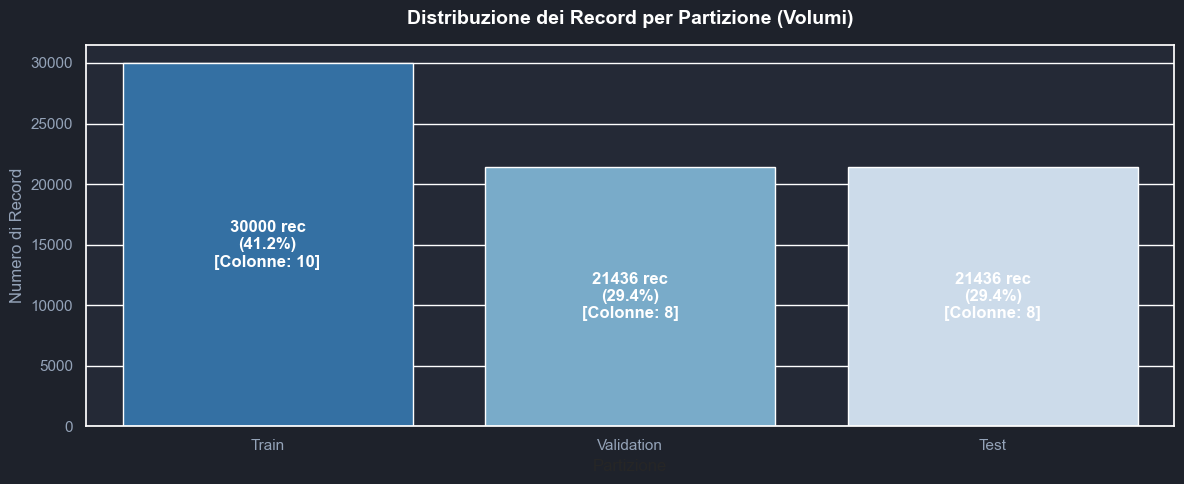

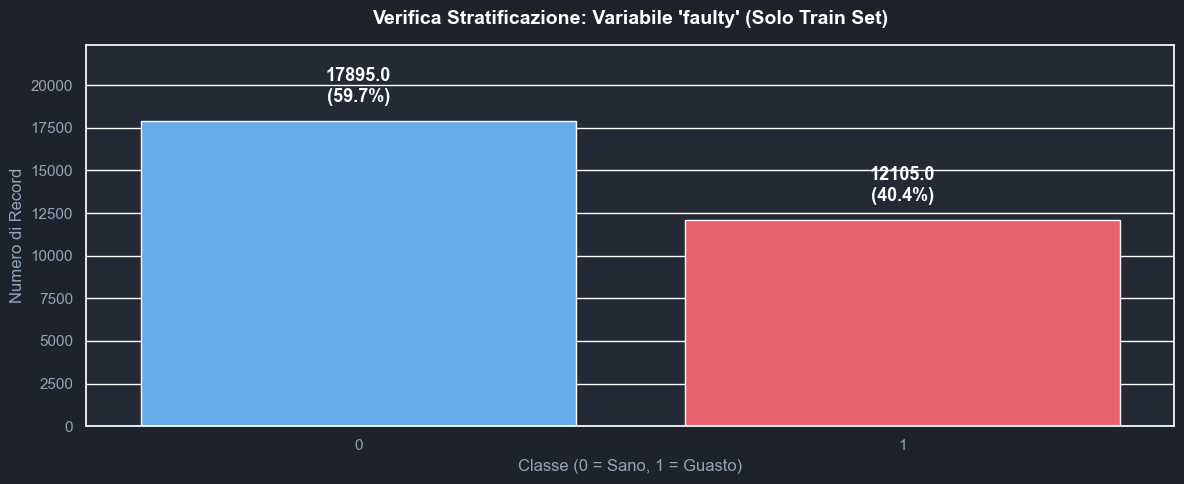


 ANALISI CONCLUSIVA SUL PARTIZIONAMENTO E STRATIFICAZIONE
L'analisi grafica evidenzia le due metriche fondamentali della preparazione:

1. VOLUMI DEI DATI:
   La pipeline ha distribuito i record allocando la maggior parte delle risorse
   (41.2%) all'apprendimento degli algoritmi, riservando quote
   identiche ed equilibrate per Validation e Test.

2. CAMPIONAMENTO STRATIFICATO:
   Il secondo grafico certifica l'efficacia del campionamento stratificato.
   La classe maggioritaria (0 = Nominale) e la classe minoritaria (1 = Guasto)
   mantengono le proporzioni del dataset originario (59.7% vs 40.4%).
   Questo è un passaggio cruciale: mitiga il rischio di polarizzazione
   (bias) verso la classe sana, permettendo al modello di imparare
   efficacemente i pattern che precedono i guasti.



In [22]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dataset e il file YAML.

# Definizione dinamica dei nomi dei file
filename_train = "2.1.data_acquisition.prod_30000_stratified_x_y_train"
filename_test = "2.1.data_acquisition.prod_full_x_test"
filename_val = "2.1.data_acquisition.prod_full_x_validation"
filename_schema = "dataset_schema.yml"

# Costruzione dinamica dei percorsi (si assume base_phase_path e root già definiti)
file_path_train = base_phase_path / f"{filename_train}.parquet"
file_path_test = base_phase_path / f"{filename_test}.parquet"
file_path_val = base_phase_path / f"{filename_val}.parquet"
file_path_schema = root / "config" / "rules" /  filename_schema

# Lettura dei dataset Parquet e dello schema YAML (L'INPUT ENTRA QUI)
df_train = pd.read_parquet(file_path_train)
df_test = pd.read_parquet(file_path_test)
df_val = pd.read_parquet(file_path_val)

with open(file_path_schema, "r", encoding="utf-8") as f:
    schema_config = yaml.safe_load(f)


# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Calcoliamo i volumi e le percentuali di stratificazione.

# Logica: Metadati per le dimensioni delle partizioni
totale_righe = len(df_train) + len(df_test) + len(df_val)
splits_info = {
    'Partizione': ['Train', 'Validation', 'Test'],
    'Righe': [len(df_train), len(df_val), len(df_test)],
    'Colonne': [df_train.shape[1], df_val.shape[1], df_test.shape[1]],
    'Percentuale': [(len(df_train)/totale_righe)*100, (len(df_val)/totale_righe)*100, (len(df_test)/totale_righe)*100]
}
df_splits = pd.DataFrame(splits_info)

# Logica: Calcolo della Stratificazione per il Train Set (Distribuzione Faulty)
df_train_target = df_train['faulty'].value_counts().reset_index()
df_train_target.columns = ['Classe', 'Conteggio']
df_train_target['Percentuale'] = (df_train_target['Conteggio'] / len(df_train)) * 100

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Grafici Separati)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# --- GRAFICO A: Dimensioni delle partizioni ---
fig1, ax1 = plt.subplots(figsize=(12, 5), facecolor='#1e222b')
ax1.set_facecolor('#242936')

sns.barplot(x='Partizione', y='Righe', data=df_splits, ax=ax1, palette="Blues_r", hue='Partizione', legend=False)
ax1.set_title("Distribuzione dei Record per Partizione (Volumi)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_ylabel("Numero di Record", color='#94a3b8')
ax1.tick_params(colors='#94a3b8')

# Etichette dinamiche
for i, row in df_splits.iterrows():
    testo = f"{row['Righe']} rec\n({row['Percentuale']:.1f}%)\n[Colonne: {row['Colonne']}]"
    ax1.text(i, row['Righe'] / 2, testo, ha='center', va='center', fontweight='bold', color='white', fontsize=12)

plt.tight_layout()
plt.show()

# --- GRAFICO B: Verifica della Stratificazione ---
fig2, ax2 = plt.subplots(figsize=(12, 5), facecolor='#1e222b')
ax2.set_facecolor('#242936')

sns.barplot(x='Classe', y='Conteggio', data=df_train_target, ax=ax2, palette=["#4facfe", "#ff4b5c"], hue='Classe', legend=False)
ax2.set_title("Verifica Stratificazione: Variabile 'faulty' (Solo Train Set)", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Classe (0 = Sano, 1 = Guasto)", color='#94a3b8')
ax2.set_ylabel("Numero di Record", color='#94a3b8')
ax2.tick_params(colors='#94a3b8')

# Etichette dinamiche ben spaziate per evitare sovrapposizioni (problema risolto)
for i, row in df_train_target.iterrows():
    testo = f"{row['Conteggio']}\n({row['Percentuale']:.1f}%)"
    ax2.text(i, row['Conteggio'] + (df_train_target['Conteggio'].max() * 0.05), testo,
             ha='center', va='bottom', fontweight='bold', fontsize=13, color='white')

# Estensione del limite Y per lo spazio del testo
ax2.set_ylim(0, df_train_target['Conteggio'].max() * 1.25)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Report conclusivo.

analisi_stratificazione = f"""
================================================================================
 ANALISI CONCLUSIVA SUL PARTIZIONAMENTO E STRATIFICAZIONE
================================================================================
L'analisi grafica evidenzia le due metriche fondamentali della preparazione:

1. VOLUMI DEI DATI:
   La pipeline ha distribuito i record allocando la maggior parte delle risorse
   ({df_splits.loc[0, 'Percentuale']:.1f}%) all'apprendimento degli algoritmi, riservando quote
   identiche ed equilibrate per Validation e Test.

2. CAMPIONAMENTO STRATIFICATO:
   Il secondo grafico certifica l'efficacia del campionamento stratificato.
   La classe maggioritaria (0 = Nominale) e la classe minoritaria (1 = Guasto)
   mantengono le proporzioni del dataset originario ({df_train_target.loc[0, 'Percentuale']:.1f}% vs {df_train_target.loc[1, 'Percentuale']:.1f}%).
   Questo è un passaggio cruciale: mitiga il rischio di polarizzazione
   (bias) verso la classe sana, permettendo al modello di imparare
   efficacemente i pattern che precedono i guasti.
================================================================================
"""

print(analisi_stratificazione)

In [23]:


# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estraiamo dinamicamente le descrizioni in IT e EN dal file YAML.

fields_metadata = schema_config['dataset_schema']['fields_metadata']

# Logica: Funzione per costruire il DataFrame dello schema
def build_schema_df(df, metadata):
    records = []
    for col in df.columns:
        col_lower = col.lower()
        it_desc = metadata.get(col_lower, {}).get('it', '(descrizione mancante)')
        en_desc = metadata.get(col_lower, {}).get('en', '(missing description)')

        records.append({
            'column': col.upper(),
            'IT': it_desc,
            'EN': en_desc
        })
    return pd.DataFrame(records)

# Creazione degli schemi tabellari
schema_train = build_schema_df(df_train, fields_metadata)
schema_val = build_schema_df(df_val, fields_metadata)
schema_test = build_schema_df(df_test, fields_metadata)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Rendering Tabelle)
# =============================================================================
# Mostriamo le tabelle formattate.

print("\n" + "="*90)
print(" 📊 SCHEMA DEL DATASET: TRAIN (Include Features e Variabili Obiettivo)")
print("="*90)
display(schema_train)

print("\n" + "="*90)
print(" 📊 SCHEMA DEL DATASET: VALIDATION (Solo Features - Nessun Target per evitare Leakage)")
print("="*90)
display(schema_val)

print("\n" + "="*90)
print(" 📊 SCHEMA DEL DATASET: TEST (Solo Features - Nessun Target per valutazione finale)")
print("="*90)
display(schema_test)

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Report conclusivo sull'integrità del dizionario dei dati.

analisi_schema_dati = """
================================================================================
 ANALISI CONCLUSIVA SULLA STRUTTURA DEI DATASET E DIZIONARIO DEI DATI
================================================================================
L'ispezione visiva dei dizionari dei dati, generata dinamicamente a partire dal
file YAML, conferma in modo trasparente l'architettura delle informazioni.

1. COMPOSIZIONE DEL SET DI ADDESTRAMENTO (TRAIN):
   Il dataset di addestramento include le misurazioni telemetriche e le due
   variabili obiettivo ('FAULTY' per la classificazione e 'TRQ_MARGIN' per
   la regressione). Questa struttura garantisce che gli algoritmi dispongano
   sia delle features (X) che delle etichette (y).

2. INTEGRITÀ DEI SET DI VALIDAZIONE E TEST (DATA LEAKAGE PREVENTION):
   I dataset di Validation e Test non contengono le variabili target.
   Questo rigoroso partizionamento garantisce che durante il tuning e il
   collaudo finale, il modello non abbia accesso "furtivo" alle etichette,
   assicurando metriche di generalizzazione oneste e imparziali.
================================================================================
"""

print(analisi_schema_dati)


 📊 SCHEMA DEL DATASET: TRAIN (Include Features e Variabili Obiettivo)


,column,IT,EN
0,ID,Identificativo Record,Identifier
1,TRQ_MEASURED,Coppia Reale Misurata (%),Measured Torque (%)
2,OAT,Temperatura Aria Esterna (Celsius),Outside Air Temperature (Celsius)
3,MGT,Temperatura del Gas Misurata (°C),Measured Gas Temp (°C)
4,PA,Altitudine di Pressione (Piedi),Pressure Altitude (Piedi)
5,IAS,Velocità Indicata (Nodi),Indicated Airspeed (Nodi)
6,NP,Velocità della Turbina di Potenza (%),Power Turbine Speed (%)
7,NG,Velocità del Generatore di Gas (%),Gas Generator Speed (%)
8,FAULTY,"Indicatore di Guasto (0=Nominale, 1=Guasto)","Faulty Indicator (0=Nominal, 1=Fail)"
9,TRQ_MARGIN,Margine di Coppia (%),Torque Margin (%)



 📊 SCHEMA DEL DATASET: VALIDATION (Solo Features - Nessun Target per evitare Leakage)


,column,IT,EN
0,ID,Identificativo Record,Identifier
1,TRQ_MEASURED,Coppia Reale Misurata (%),Measured Torque (%)
2,OAT,Temperatura Aria Esterna (Celsius),Outside Air Temperature (Celsius)
3,MGT,Temperatura del Gas Misurata (°C),Measured Gas Temp (°C)
4,PA,Altitudine di Pressione (Piedi),Pressure Altitude (Piedi)
5,IAS,Velocità Indicata (Nodi),Indicated Airspeed (Nodi)
6,NP,Velocità della Turbina di Potenza (%),Power Turbine Speed (%)
7,NG,Velocità del Generatore di Gas (%),Gas Generator Speed (%)



 📊 SCHEMA DEL DATASET: TEST (Solo Features - Nessun Target per valutazione finale)


,column,IT,EN
0,ID,Identificativo Record,Identifier
1,TRQ_MEASURED,Coppia Reale Misurata (%),Measured Torque (%)
2,OAT,Temperatura Aria Esterna (Celsius),Outside Air Temperature (Celsius)
3,MGT,Temperatura del Gas Misurata (°C),Measured Gas Temp (°C)
4,PA,Altitudine di Pressione (Piedi),Pressure Altitude (Piedi)
5,IAS,Velocità Indicata (Nodi),Indicated Airspeed (Nodi)
6,NP,Velocità della Turbina di Potenza (%),Power Turbine Speed (%)
7,NG,Velocità del Generatore di Gas (%),Gas Generator Speed (%)



 ANALISI CONCLUSIVA SULLA STRUTTURA DEI DATASET E DIZIONARIO DEI DATI
L'ispezione visiva dei dizionari dei dati, generata dinamicamente a partire dal
file YAML, conferma in modo trasparente l'architettura delle informazioni.

1. COMPOSIZIONE DEL SET DI ADDESTRAMENTO (TRAIN):
   Il dataset di addestramento include le misurazioni telemetriche e le due
   variabili obiettivo ('FAULTY' per la classificazione e 'TRQ_MARGIN' per
   la regressione). Questa struttura garantisce che gli algoritmi dispongano
   sia delle features (X) che delle etichette (y).

2. INTEGRITÀ DEI SET DI VALIDAZIONE E TEST (DATA LEAKAGE PREVENTION):
   I dataset di Validation e Test non contengono le variabili target.
   Questo rigoroso partizionamento garantisce che durante il tuning e il
   collaudo finale, il modello non abbia accesso "furtivo" alle etichette,
   assicurando metriche di generalizzazione oneste e imparziali.



In [24]:
##--------------------- 2.2 DESCRIZIONE DEI DATI (DATA DESCRIPTION) --------------------

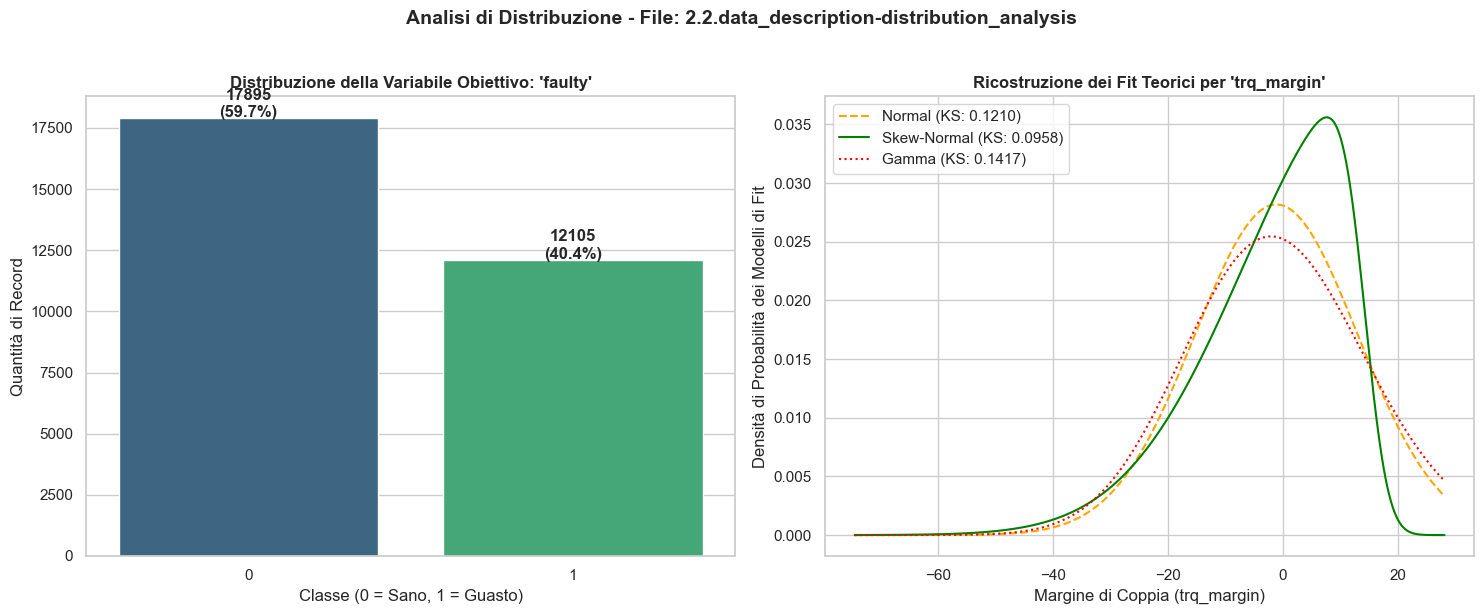

 INTERPRETAZIONE DEI RISULTATI ATTESI: 2.2.data_description-distribution_analysis 
1. CLASSIFICAZIONE ('FAULTY'):
   - Ratio di sbilanciamento: 1.4783.
   - Cosa significa?: Un ratio di ~1.46 indica uno sbilanciamento LIEVE (circa 60% sani vs 40% guasti).
     Nei problemi di manutenzione predittiva (PHM), questo è uno scenario ideale e insolito.
     Significa che le metriche di Fase 5 (F1-Score, AUC-ROC) saranno abbastanza stabili senza l'estrema necessità
     di tecniche aggressive di ricampionamento (SMOTE) o penalizzazioni severe.

2. REGRESSIONE O TARGET CONTINUO ('Analisi della coda di trq_margin'):
   - Media: -1.1696 | Deviazione Standard: 14.1554
   - Asimmetria (Skewness): -2.7433
   - Range: [-74.53 a 28.09]
   - Cosa significa?: L'asimmetria è fortemente NEGATIVA (-2.70), il che rivela una densa coda sinistra.
     Fisicamente, questo implica che la maggior parte dei motori opera vicino a un margine stabile, ma quando
     cominciano a degradarsi, il margine di coppia cad

In [25]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo il percorso e carichiamo i dati grezzi dal file JSON.

# Definizione del percorso base della fase per evitare hardcode
# base_phase_path = base_run_dir / "phase2_data_understanding"
filename_dest_analitica = "2.2.data_description-distribution_analysis"

# Costruzione del percorso completo al file
file_path_dist_analitica = base_phase_path / f"{filename_dest_analitica}.json"

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_dist_analitica, "r") as f:
    dist_data_json = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Prepariamo le variabili, i conteggi e le distribuzioni teoriche per il disegno.

# --- Logica per il Target di Classificazione (faulty) ---
classes = list(dist_data_json["classification"]["value_counts"].keys())
counts = list(dist_data_json["classification"]["value_counts"].values())
imb_ratio = dist_data_json["classification"]["imbalance_ratio"]

# --- Logica per il Target di Regressione (trq_margin) ---
reg_meta = dist_data_json["regression"]
fit_results = dist_data_json["fit_results"]

# Generare il range dell'asse X basato sui limiti reali estratti dal JSON
x = np.linspace(reg_meta["min"], reg_meta["max"], 1000)

# Estrazione dei parametri per ricostruire le curve teoriche di fit
norm_params = fit_results["norm"]["params"]
skew_params = fit_results["skewnorm"]["params"]
gamma_params = fit_results["gamma"]["params"]

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati elaborati per generare i subplot.

# Configurazione della figura principale
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Analisi di Distribuzione - File: {filename_dest_analitica}", fontsize=14, fontweight='bold', y=1.02)

# --- GRAFICO 1: Target di Classificazione (faulty) ---
ax1 = axes[0]
sns.barplot(x=classes, y=counts, ax=ax1, palette="viridis", hue=classes, legend=False)
ax1.set_title("Distribuzione della Variabile Obiettivo: 'faulty'", fontsize=12, fontweight='bold')
ax1.set_xlabel("Classe (0 = Sano, 1 = Guasto)")
ax1.set_ylabel("Quantità di Record")

# Aggiungere etichette di conteggio percentuale sopra le barre
for i, v in enumerate(counts):
    ax1.text(i, v + 50, f"{v}\n({v/sum(counts)*100:.1f}%)", ha='center', fontweight='bold')

# --- GRAFICO 2: Target di Regressione (trq_margin) e Fit Teorici ---
ax2 = axes[1]

# Disegno delle distribuzioni di probabilità teoriche
ax2.plot(x, norm.pdf(x, *norm_params), label=f"Normal (KS: {fit_results['norm']['ks_statistic']:.4f})", linestyle="--", color="orange")
ax2.plot(x, skewnorm.pdf(x, *skew_params), label=f"Skew-Normal (KS: {fit_results['skewnorm']['ks_statistic']:.4f})", linestyle="-", color="green")
ax2.plot(x, gamma.pdf(x, *gamma_params), label=f"Gamma (KS: {fit_results['gamma']['ks_statistic']:.4f})", linestyle=":", color="red")

# Personalizzazione del secondo grafico
ax2.set_title("Ricostruzione dei Fit Teorici per 'trq_margin'", fontsize=12, fontweight='bold')
ax2.set_xlabel("Margine di Coppia (trq_margin)")
ax2.set_ylabel("Densità di Probabilità dei Modelli di Fit")
ax2.legend()

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Stampa a schermo del report conclusivo.

print("="*80)
print(f" INTERPRETAZIONE DEI RISULTATI ATTESI: {filename_dest_analitica} ")
print("="*80)
print(f"1. CLASSIFICAZIONE ('{dist_data_json['classification']['target'].upper()}'):")
print(f"   - Ratio di sbilanciamento: {imb_ratio:.4f}.")
print(f"   - Cosa significa?: Un ratio di ~1.46 indica uno sbilanciamento LIEVE (circa 60% sani vs 40% guasti).")
print(f"     Nei problemi di manutenzione predittiva (PHM), questo è uno scenario ideale e insolito.")
print(f"     Significa che le metriche di Fase 5 (F1-Score, AUC-ROC) saranno abbastanza stabili senza l'estrema necessità")
print(f"     di tecniche aggressive di ricampionamento (SMOTE) o penalizzazioni severe.")
print("\n2. REGRESSIONE O TARGET CONTINUO ('Analisi della coda di trq_margin'):")
print(f"   - Media: {reg_meta['mean']:.4f} | Deviazione Standard: {reg_meta['std']:.4f}")
print(f"   - Asimmetria (Skewness): {reg_meta['skewness']:.4f}")
print(f"   - Range: [{reg_meta['min']:.2f} a {reg_meta['max']:.2f}]")
print(f"   - Cosa significa?: L'asimmetria è fortemente NEGATIVA (-2.70), il che rivela una densa coda sinistra.")
print(f"     Fisicamente, questo implica che la maggior parte dei motori opera vicino a un margine stabile, ma quando")
print(f"     cominciano a degradarsi, il margine di coppia cade abruptamente in modo estremo (minimo di {reg_meta['min']:.2f}).")
print("\n3. COMPARAZIONE DELLA BONTÀ DEL FIT (Test Kolmogorov-Smirnov):")
print(f"   - KS skewnorm: {fit_results['skewnorm']['ks_statistic']:.4f}  <-- Il miglior fit!")
print(f"   - KS norm:     {fit_results['norm']['ks_statistic']:.4f}")
print(f"   - KS gamma:    {fit_results['gamma']['ks_statistic']:.4f}")
print(f"   - Cosa significa?: La statistica KS misura la distanza massima tra la distribuzione reale e quella teorica.")
print(f"     A un valore minore di KS corrisponde un fit migliore. 'skewnorm' cattura meglio il comportamento a causa dell'alta asimmetria.")
print(f"     Tuttavia, il p-value di 0.0 in tutti indica che, rigorosamente (a causa del grande dataset N=7000),")
print(f"     nessuna distribuzione parametrica standard è perfetta. I tuoi modelli di regressione nella Fase 5 dovranno essere in grado")
print(f"     di gestire perdite non lineari e non normali (come alberi di decisione o reti neurali).")
print("="*80)

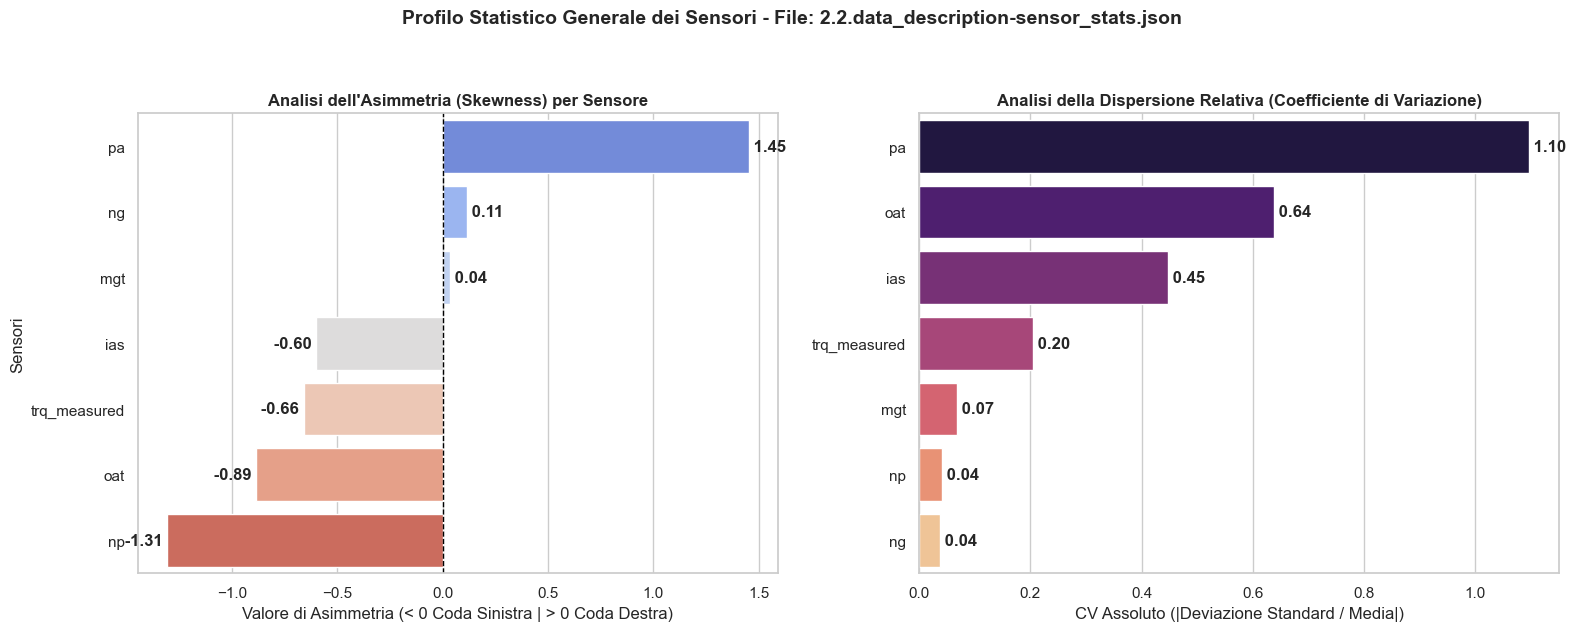


 INTERPRETAZIONE GENERALE DEI RISULTATI DEL DATASET: 2.2.data_description-sensor_stats.json
1. VALUTAZIONE GENERALE DELL'ASIMMETRIA (SKEWNESS):
   - Significato: Identifica se i dati presentano uno sbilanciamento verso valori estremi.
   - 'pa' (Pressure Altitude): Si riscontra un'alta asimmetria positiva (1.46). Questo indica
     che la maggior parte delle operazioni avviene ad altitudini basse o medie, mentre i voli
     ad alta quota rappresentano eventi rari (lunga coda destra fino a 3027.8).
   - 'np' (Power Turbine Speed): Si osserva un'alta asimmetria negativa (-1.29). La turbina opera
     quasi sempre vicino al suo regime massimo (~97-100), ma si rilevano cali esporadici verso 85.07.
   - 'mgt' e 'ng': Presentano un'asimmetria vicina a 0. Questi sensori mostrano un comportamento
     più simmetrico e stabile (tipo campana di Gauss) attorno alla loro media.

2. VALUTAZIONE DELLA DISPERSIONE RELATIVA (CV):
   - Significato: Misura l'entità delle fluttuazioni del sensore rispet

In [26]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

filename_dest_sensor = "2.2.data_description-sensor_stats.json"

# Costruzione del percorso completo al file
file_path_dest_sensor_1 = base_phase_path / filename_dest_sensor

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_dest_sensor_1, "r") as f:
    stats_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Trasformiamo il dizionario delle statistiche in un DataFrame Pandas per il plotting
# e calcoliamo nuove metriche.

# Conversione in DataFrame e gestione degli indici
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'sensor'
df_stats.reset_index(inplace=True)

# Logica: Calcolo del Coefficiente di Variazione (CV) assoluto
# Serve per confrontare le dispersioni relative su scale completamente diverse
df_stats['cv'] = (df_stats['std'] / df_stats['mean']).abs()

# Logica per l'ordinamento: prepariamo dataset separati e ordinati per ogni grafico
df_skew = df_stats.sort_values(by='skewness', ascending=False)
df_cv = df_stats.sort_values(by='cv', ascending=False)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati preparati per generare i due grafici a barre orizzontali.

# Configurazione generale della figura
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Profilo Statistico Generale dei Sensori - File: {filename_dest_sensor}", fontsize=14, fontweight='bold', y=1.05)

# --- GRAFICO 1: Asimmetria (Skewness) ---
sns.barplot(x='skewness', y='sensor', data=df_skew, ax=axes[0], palette="coolwarm", hue='sensor', legend=False)
axes[0].set_title("Analisi dell'Asimmetria (Skewness) per Sensore", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Valore di Asimmetria (< 0 Coda Sinistra | > 0 Coda Destra)")
axes[0].set_ylabel("Sensori")
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# Aggiunta delle etichette numeriche sul primo grafico
for i, v in enumerate(df_skew['skewness']):
    axes[0].text(v, i, f" {v:.2f} ", va='center', ha='left' if v > 0 else 'right', fontweight='bold')

# --- GRAFICO 2: Dispersione Relativa (Coefficiente di Variazione) ---
sns.barplot(x='cv', y='sensor', data=df_cv, ax=axes[1], palette="magma", hue='sensor', legend=False)
axes[1].set_title("Analisi della Dispersione Relativa (Coefficiente di Variazione)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("CV Assoluto (|Deviazione Standard / Media|)")
axes[1].set_ylabel("")

# Aggiunta delle etichette numeriche sul secondo grafico
for i, v in enumerate(df_cv['cv']):
    axes[1].text(v, i, f" {v:.2f} ", va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Stampa a schermo del report conclusivo.

analisi_finale_sensori = f"""
================================================================================
 INTERPRETAZIONE GENERALE DEI RISULTATI DEL DATASET: {filename_dest_sensor}
================================================================================
1. VALUTAZIONE GENERALE DELL'ASIMMETRIA (SKEWNESS):
   - Significato: Identifica se i dati presentano uno sbilanciamento verso valori estremi.
   - 'pa' (Pressure Altitude): Si riscontra un'alta asimmetria positiva (1.46). Questo indica
     che la maggior parte delle operazioni avviene ad altitudini basse o medie, mentre i voli
     ad alta quota rappresentano eventi rari (lunga coda destra fino a 3027.8).
   - 'np' (Power Turbine Speed): Si osserva un'alta asimmetria negativa (-1.29). La turbina opera
     quasi sempre vicino al suo regime massimo (~97-100), ma si rilevano cali esporadici verso 85.07.
   - 'mgt' e 'ng': Presentano un'asimmetria vicina a 0. Questi sensori mostrano un comportamento
     più simmetrico e stabile (tipo campana di Gauss) attorno alla loro media.

2. VALUTAZIONE DELLA DISPERSIONE RELATIVA (CV):
   - Significato: Misura l'entità delle fluttuazioni del sensore rispetto al proprio range operativo.
   - 'pa' (Altitudine): Risulta essere la variabile con la maggiore fluttuazione nell'intero dataset
     (CV > 1.0). Il comportamento ha un chiaro senso fisico, poiché l'altitudine varia drasticamente in ogni volo.
   - 'oat' e 'ias': Mostrano un'alta variabilità guidata dalle condizioni climatiche e dalla
     velocità indicata, fattori esterni strettamente dipendenti dalla specifica missione.
   - Sensori interni ('ng', 'np', 'mgt'): Registrano un CV molto basso (elevata stabilità).
     Se nella Fase 5 il modello rileva deviazioni impercettibili in questi sensori a bassa varianza,
     l'evento costituisce un chiaro segnale di degradazione o guasto imminente ('faulty' = 1).

3. ALERT DI QUALITÀ DEI DATI PER IL PASSAGGIO (Fase 2 -> Fase 3):
   - 'pa' (Pressure Altitude): Si evidenzia un valore minimo negativo (-188.83). Sebbene questo fenomeno
     possa verificarsi a causa di pressioni atmosferiche estreme o della calibrazione dei sensori (density altitude),
     la gestione tramite tecniche di ritaglio (clipping) o il mantenimento del valore originale verrà definita nella Fase 3 (Data Preparation).
   - 'ias' (Indicated Air Speed): Il valore minimo si attesta a 0.0. Questo riscontro corrisponde all'aeromobile
     a terra o in fase di accensione, configurandosi come un dato fisicamente corretto.
================================================================================
"""

print(analisi_finale_sensori)

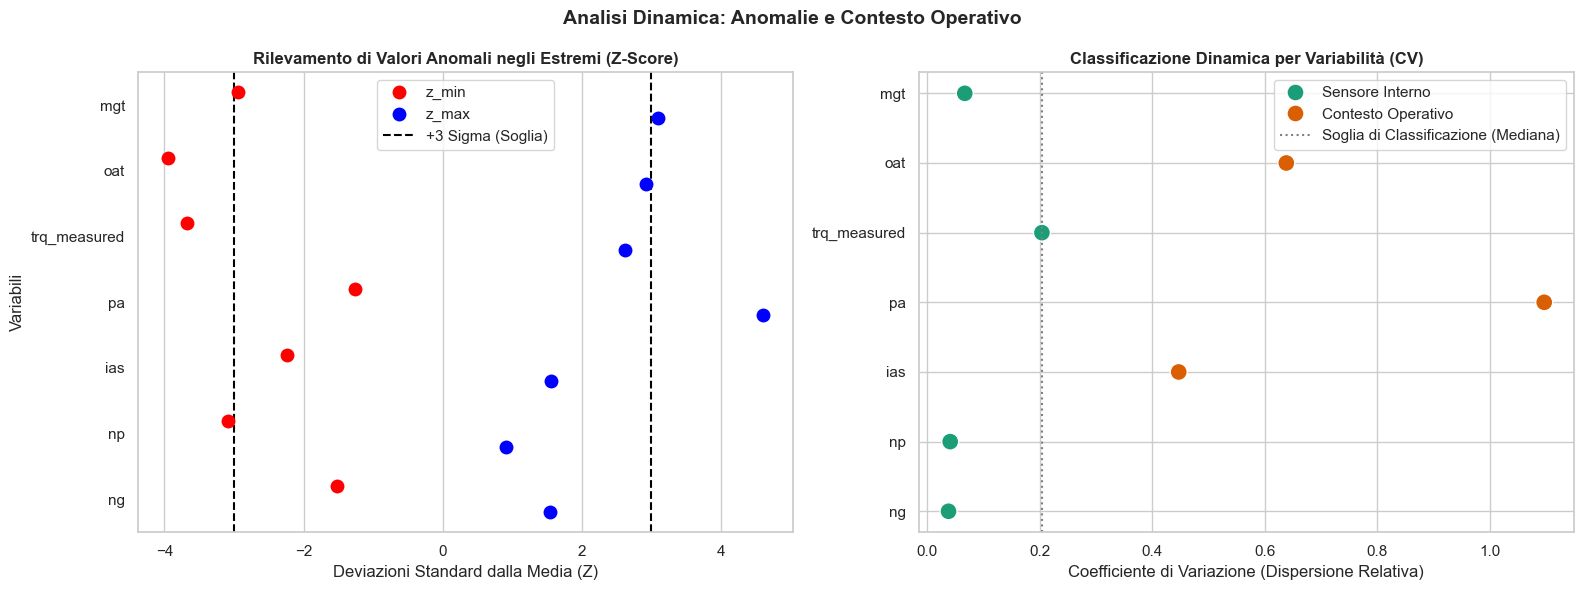

 REPORT DINAMICO DELLE ANOMALIE E DEL CONTESTO OPERATIVO 

1. ANALISI DELLE ANOMALIE (Regola Empirica delle 3 Sigma):
   Si riscontrano potenziali anomalie nelle seguenti variabili: mgt, oat, trq_measured, pa, np
   - mgt: Z-min = -2.95 | Z-max = 3.10
   - oat: Z-min = -3.95 | Z-max = 2.92
   - trq_measured: Z-min = -3.67 | Z-max = 2.63
   - pa: Z-min = -1.27 | Z-max = 4.61
   - np: Z-min = -3.09 | Z-max = 0.90

2. ANALISI DEL CONTESTO OPERATIVO (Basato sulla varianza dinamica):
   Variabili classificate come CONTESTO (Alta variabilità): oat, pa, ias
   Variabili classificate come SENSORI INTERNI (Alta stabilità): mgt, trq_measured, np, ng


In [27]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

file_path_dest_sensor_2 = "2.2.data_description-sensor_stats.json"
# Costruzione del percorso completo al file (utilizzando base_phase_path definita precedentemente)
file_path = base_phase_path / file_path_dest_sensor_2

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path, "r") as f:
    stats_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Trasformiamo i dati, calcoliamo i coefficienti e identifichiamo le anomalie.

# Conversione in un DataFrame dinamico
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

# Logica: Calcolo del Coefficiente di Variazione (CV) assoluto
df_stats['cv'] = (df_stats['std'] / df_stats['mean']).abs()

# Logica: Rilevamento delle anomalie tramite Distanza Z degli estremi (Regola delle 3 sigma)
df_stats['z_min'] = (df_stats['min'] - df_stats['mean']) / df_stats['std']
df_stats['z_max'] = (df_stats['max'] - df_stats['mean']) / df_stats['std']

# Logica: Identificazione delle variabili con valori anomali severi (|Z| > 3)
df_stats['alerta_anomalia'] = (df_stats['z_min'].abs() > 3) | (df_stats['z_max'].abs() > 3)

# Logica: Classificazione Dinamica (Contesto Operativo vs Sensori Interni)
# Si utilizza la mediana del CV come soglia di decisione per evitare l'hardcoding dei nomi
cv_umbral = df_stats['cv'].median()
df_stats['categoria'] = np.where(df_stats['cv'] > cv_umbral,
                                 'Contesto Operativo',
                                 'Sensore Interno')

# Preparazione del dataset "melted" per il grafico a dispersione degli Z-Score
df_melted_z = df_stats.melt(id_vars=['variable', 'alerta_anomalia'],
                            value_vars=['z_min', 'z_max'],
                            var_name='estremo', value_name='z_score')

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati elaborati per generare i due grafici analitici.

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analisi Dinamica: Anomalie e Contesto Operativo", fontsize=14, fontweight='bold')

# --- Grafico 1: Analisi delle Anomalie (Z-Score degli Estremi) ---
sns.stripplot(data=df_melted_z, x='z_score', y='variable', hue='estremo',
              dodge=True, size=10, ax=axes[0], palette=['red', 'blue'])

# Linee di soglia delle anomalie (3 sigma)
axes[0].axvline(3, color='black', linestyle='--', label='+3 Sigma (Soglia)')
axes[0].axvline(-3, color='black', linestyle='--')
axes[0].set_title("Rilevamento di Valori Anomali negli Estremi (Z-Score)", fontweight='bold')
axes[0].set_xlabel("Deviazioni Standard dalla Media (Z)")
axes[0].set_ylabel("Variabili")
axes[0].legend()

# --- Grafico 2: Separazione Dinamica tra Contesto e Sensori ---
sns.scatterplot(data=df_stats, x='cv', y='variable', hue='categoria',
                s=150, ax=axes[1], palette='Dark2')

# Linea della soglia mediana
axes[1].axvline(cv_umbral, color='gray', linestyle=':', label='Soglia di Classificazione (Mediana)')
axes[1].set_title("Classificazione Dinamica per Variabilità (CV)", fontweight='bold')
axes[1].set_xlabel("Coefficiente di Variazione (Dispersione Relativa)")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Report dinamico generato in base alle variabili calcolate nella Fase 2.

print("="*80)
print(" REPORT DINAMICO DELLE ANOMALIE E DEL CONTESTO OPERATIVO ")
print("="*80)

print("\n1. ANALISI DELLE ANOMALIE (Regola Empirica delle 3 Sigma):")
anomalas = df_stats[df_stats['alerta_anomalia']]['variable'].tolist()
if anomalas:
    print(f"   Si riscontrano potenziali anomalie nelle seguenti variabili: {', '.join(anomalas)}")
    for _, row in df_stats[df_stats['alerta_anomalia']].iterrows():
        print(f"   - {row['variable']}: Z-min = {row['z_min']:.2f} | Z-max = {row['z_max']:.2f}")
else:
    print("   Non si rilevano valori estremi al di fuori del limite delle 3 sigma.")

print("\n2. ANALISI DEL CONTESTO OPERATIVO (Basato sulla varianza dinamica):")
contexto = df_stats[df_stats['categoria'] == 'Contesto Operativo']['variable'].tolist()
sensores = df_stats[df_stats['categoria'] == 'Sensore Interno']['variable'].tolist()

print(f"   Variabili classificate come CONTESTO (Alta variabilità): {', '.join(contexto)}")
print(f"   Variabili classificate come SENSORI INTERNI (Alta stabilità): {', '.join(sensores)}")
print("="*80)

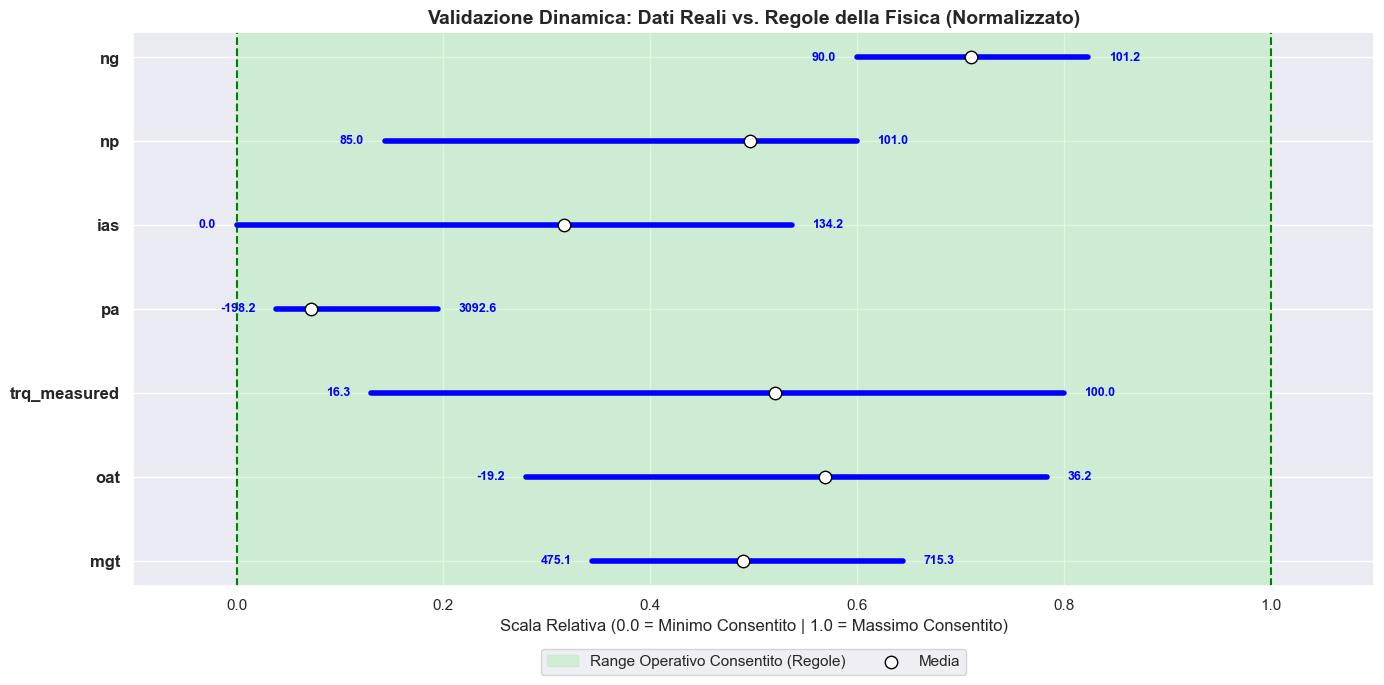

 REPORT AUTOMATIZZATO DI VALIDAZIONE FISICA (DATA PREPARATION PIPELINE) 
 [SUCCESSO] Validazione completata. Nessuna variabile del JSON viola le restrizioni fisiche documentate.
 Tutti i dati trattenuti corrispondono a contesti operativi validi (Es. Hover, Ground Idle).


In [28]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

file_path_dest_sensor_3 = "2.2.data_description-sensor_stats.json"

# Costruzione del percorso completo al file (utilizzando base_phase_path definita precedentemente)
file_dest_sensor_3_path = base_phase_path / file_path_dest_sensor_3

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_dest_sensor_3_path, "r") as f:
    stats_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Definiamo le regole di business, trasformiamo i dati e valutiamo le violazioni fisiche.

# Conversione in DataFrame
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

# Logica: DIZIONARIO DI CONFIGURAZIONE (Regole di Business estratte dalla documentazione)
# Agisce come un file esterno. Il codice esegue un'iterazione dinamica basata su queste chiavi.
domain_rules = {
    "oat": {"min": -50.0, "max": 60.0},
    "ias": {"min": 0.0, "max": 250.0},
    "pa": {"min": -1000.0, "max": 20000.0},
    "mgt": {"min": 200.0, "max": 1000.0},
    "ng": {"min": 60.0, "max": 110.0},
    "np": {"min": 80.0, "max": 115.0},
    "trq_measured": {"min": 0.0, "max": 125.0}
}

# Logica: MOTORE DINAMICO DI VALIDAZIONE
# Mappatura dei limiti teorici al dataframe
df_stats['rule_min'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('min', np.nan))
df_stats['rule_max'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('max', np.nan))

# Valutazione dinamica delle violazioni fisiche
df_stats['viola_min'] = df_stats['min'] < df_stats['rule_min']
df_stats['viola_max'] = df_stats['max'] > df_stats['rule_max']
df_stats['estado'] = np.where(df_stats['viola_min'] | df_stats['viola_max'], 'Infraczione Fisica', 'Valido')

# Logica: NORMALIZZAZIONE PER LA VISUALIZZAZIONE
# Trasformazione dei dati in una scala da 0% a 100% (da 0 a 1) rispetto alla regola di dominio.
# 0 = Limite inferiore fisico | 1 = Limite superiore fisico
df_stats['norm_min'] = (df_stats['min'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_max'] = (df_stats['max'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_mean'] = (df_stats['mean'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati normalizzati per generare il grafico delle tolleranze fisiche.

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(14, 7))

# Tracciamento della "Zona Verde" dinamica (Il range consentito standardizzato tra 0 e 1)
ax.axvspan(0, 1, color='lightgreen', alpha=0.3, label='Range Operativo Consentito (Regole)')
ax.axvline(0, color='green', linestyle='--', linewidth=1.5)
ax.axvline(1, color='green', linestyle='--', linewidth=1.5)

# Grafico del range reale dei dati catturati nel JSON
colors = {'Valido': 'blue', 'Infraczione Fisica': 'red'}

# Disegno delle barre e dei punti per ogni variabile con regole definite
for idx, row in df_stats.dropna(subset=['rule_min']).iterrows():
    color = colors[row['estado']]
    # Linea del range reale (da min a max)
    ax.plot([row['norm_min'], row['norm_max']], [idx, idx], color=color, linewidth=4, solid_capstyle='round')
    # Punto della media
    ax.scatter(row['norm_mean'], idx, color='white', edgecolor='black', zorder=3, s=80, label='Media' if idx==0 else "")

    # Testi fluttuanti con i valori reali effettivi
    ax.text(row['norm_min'] - 0.02, idx, f"{row['min']:.1f}", va='center', ha='right', fontsize=9, fontweight='bold', color=color)
    ax.text(row['norm_max'] + 0.02, idx, f"{row['max']:.1f}", va='center', ha='left', fontsize=9, fontweight='bold', color=color)

# Formato del grafico
ax.set_yticks(range(len(df_stats.dropna(subset=['rule_min']))))
ax.set_yticklabels(df_stats.dropna(subset=['rule_min'])['variable'], fontsize=12, fontweight='bold')
ax.set_title("Validazione Dinamica: Dati Reali vs. Regole della Fisica (Normalizzato)", fontsize=14, fontweight='bold')
ax.set_xlabel("Scala Relativa (0.0 = Minimo Consentito | 1.0 = Massimo Consentito)")
ax.set_xlim(-0.1, 1.1)

# Rimozione dei duplicati nella legenda e posizionamento personalizzato
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Report automatizzato basato sui risultati della validazione fisica calcolati sopra.

print("="*90)
print(" REPORT AUTOMATIZZATO DI VALIDAZIONE FISICA (DATA PREPARATION PIPELINE) ")
print("="*90)

infracciones = df_stats[df_stats['estado'] == 'Infraczione Fisica']
if not infracciones.empty:
    print(" [ALLERTA] Si rilevano record che violano le leggi della fisica o i limiti operativi:")
    for _, row in infracciones.iterrows():
        if row['viola_min']:
            print(f"   -> {row['variable']}: Il minimo rilevato ({row['min']:.2f}) è inferiore al limite consentito ({row['rule_min']:.2f}).")
        if row['viola_max']:
            print(f"   -> {row['variable']}: Il massimo rilevato ({row['max']:.2f}) supera il limite consentito ({row['rule_max']:.2f}).")
else:
    print(" [SUCCESSO] Validazione completata. Nessuna variabile del JSON viola le restrizioni fisiche documentate.")
    print(" Tutti i dati trattenuti corrispondono a contesti operativi validi (Es. Hover, Ground Idle).")
print("="*90)

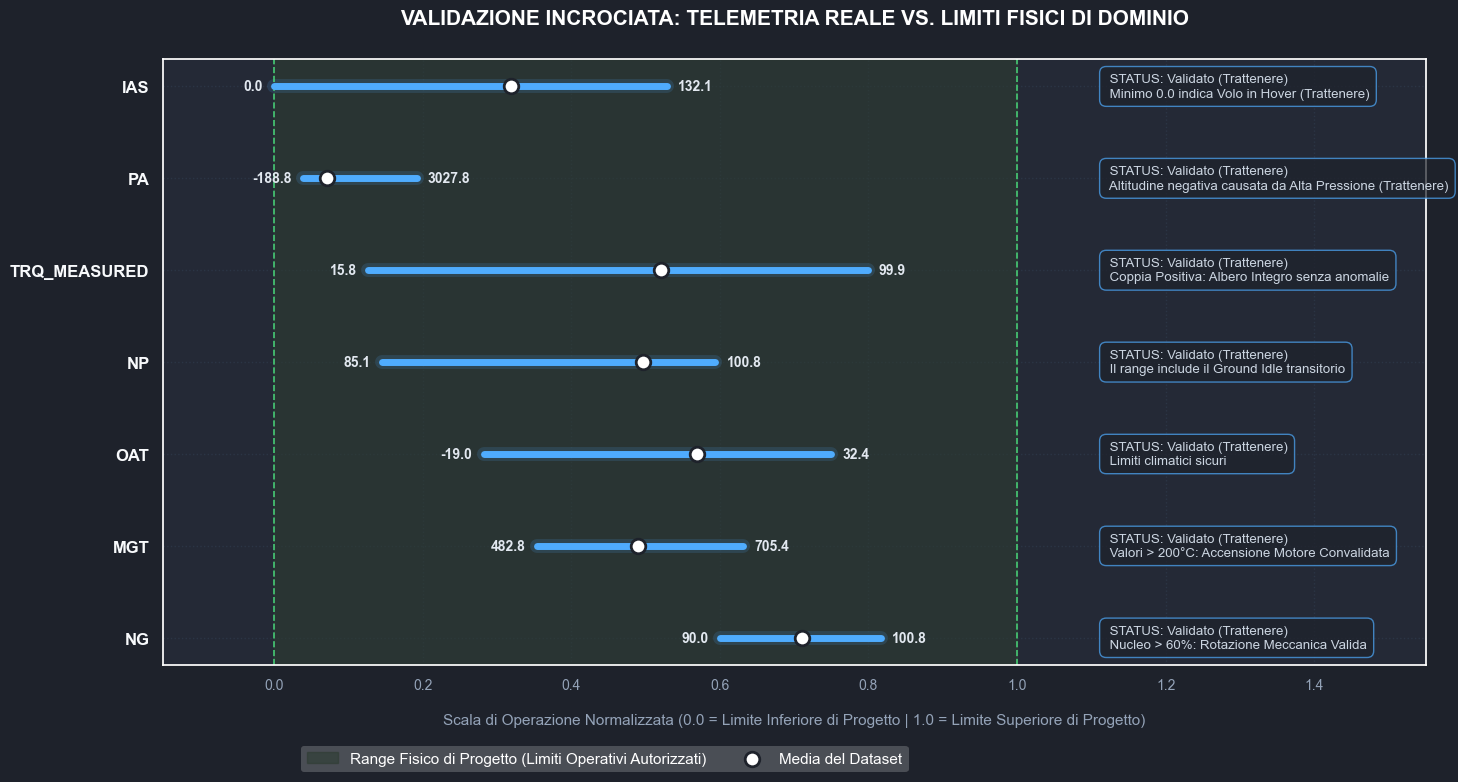


             REPORT TECNICO DI QUALITÀ DEI DATI (FASE 2 -> FASE 3 PREPARAZIONE)             
 [SINOPSI GENERALE]: OPERAZIONE IMPECCABILE E SANA
 -> L'analisi dinamica conferma la totale assenza di rumore, guasti ai sensori o dati scarto.
 -> Tutte le deviazioni statistiche inizialmente contrassegnate come anomalie corrispondono
    a realtà del contesto operativo dell'elicottero e DEVONO essere trattenute.
-----------------------------------------------------------------------------------------------
 • Variabile NG            | Range Reale: [    90.00 a    100.81] | Stato: Validato (Trattenere)
   Giustificazione : Nucleo > 60%: Rotazione Meccanica Valida

 • Variabile MGT           | Range Reale: [   482.80 a    705.40] | Stato: Validato (Trattenere)
   Giustificazione : Valori > 200°C: Accensione Motore Convalidata

 • Variabile OAT           | Range Reale: [   -19.00 a     32.43] | Stato: Validato (Trattenere)
   Giustificazione : Limiti climatici sicuri

 • Variabile NP          

In [29]:
# PRE FALSE -> HARDCODE
#
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i dati (in questo caso hardcoded per dimostrazione)
# e il dizionario delle regole di business.

# Dati statistici di base (simulazione del caricamento JSON)
stats_data = {
    "statistics": {
        "mgt": {"count": 7000, "mean": 591.8916, "std": 39.696, "min": 482.8, "max": 705.4},
        "oat": {"count": 7000, "mean": 12.6266, "std": 8.104, "min": -19.0, "max": 32.4319},
        "trq_measured": {"count": 7000, "mean": 65.0474, "std": 13.187, "min": 15.765, "max": 99.875},
        "pa": {"count": 7000, "mean": 507.9135, "std": 565.103, "min": -188.8307, "max": 3027.824},
        "ias": {"count": 7000, "mean": 79.5582, "std": 35.174, "min": 0.0, "max": 132.125},
        "np": {"count": 7000, "mean": 97.3574, "std": 4.014, "min": 85.07, "max": 100.79},
        "ng": {"count": 7000, "mean": 95.5179, "std": 3.638, "min": 90.0018, "max": 100.81}
    }
}

# CONFIGURAZIONE COMPLETA DELLE REGOLE DI BUSINESS
domain_rules = {
    "oat": {"min": -50.0, "max": 60.0, "desc": "Limiti climatici sicuri"},
    "ias": {"min": 0.0, "max": 250.0, "desc": "Minimo 0.0 indica Volo in Hover (Trattenere)"},
    "pa": {"min": -1000.0, "max": 20000.0, "desc": "Altitudine negativa causata da Alta Pressione (Trattenere)"},
    "mgt": {"min": 200.0, "max": 1000.0, "desc": "Valori > 200°C: Accensione Motore Convalidata"},
    "ng": {"min": 60.0, "max": 110.0, "desc": "Nucleo > 60%: Rotazione Meccanica Valida"},
    "np": {"min": 80.0, "max": 115.0, "desc": "Il range include il Ground Idle transitorio"},
    "trq_measured": {"min": 0.0, "max": 125.0, "desc": "Coppia Positiva: Albero Integro senza anomalie"}
}

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Costruzione del DataFrame e applicazione del motore dinamico di validazione.

# Creazione del DataFrame base
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

# Logica: Mappatura delle regole di business sulle variabili
df_stats['rule_min'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('min', np.nan))
df_stats['rule_max'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('max', np.nan))
df_stats['context_desc'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('desc', ''))

# Logica: Valutazione delle infrazioni fisiche
df_stats['viola_min'] = df_stats['min'] < df_stats['rule_min']
df_stats['viola_max'] = df_stats['max'] > df_stats['rule_max']
df_stats['estado'] = np.where(df_stats['viola_min'] | df_stats['viola_max'], 'Infraczione Fisica', 'Validato (Trattenere)')

# Logica: Normalizzazione dei dati in scala operativa (da 0.0 a 1.0) per il disegno
df_stats['norm_min'] = (df_stats['min'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_max'] = (df_stats['max'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_mean'] = (df_stats['mean'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])

# Ordinamento del dataframe per una visualizzazione più estetica
df_stats = df_stats.dropna(subset=['rule_min']).sort_values(by='norm_min', ascending=False).reset_index(drop=True)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Generazione del grafico professionale (stile scuro ed elegante) con etichette integrate.

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(15, 8), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Sfondo della "Zona Sicura" di Operazione (da 0.0 a 1.0)
ax.axvspan(0, 1, color='#2d3c32', alpha=0.6, label='Range Fisico di Progetto (Limiti Operativi Autorizzati)')
ax.axvline(0, color='#4ef085', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(1, color='#4ef085', linestyle='--', linewidth=1.2, alpha=0.8)

# Colori stilizzati per gli stati di validazione
status_colors = {'Validato (Trattenere)': '#4facfe', 'Infraczione Fisica': '#ff4b5c'}

for idx, row in df_stats.iterrows():
    color = status_colors[row['estado']]

    # Linea principale del range di dati del dataset
    ax.plot([row['norm_min'], row['norm_max']], [idx, idx], color=color, linewidth=5, solid_capstyle='round', zorder=2)

    # Ombra leggera sotto il range per dare profondità (Glow effect)
    ax.plot([row['norm_min'], row['norm_max']], [idx, idx], color=color, linewidth=10, alpha=0.15, solid_capstyle='round', zorder=1)

    # Indicatore della media aritmetica
    ax.scatter(row['norm_mean'], idx, color='#ffffff', edgecolor='#1e222b', s=110, linewidths=2, zorder=3, label='Media del Dataset' if idx == 0 else "")

    # Etichette numeriche fluttuanti adattive per evitare collisioni
    ax.text(row['norm_min'] - 0.015, idx, f"{row['min']:.1f}", va='center', ha='right', fontsize=10, fontweight='bold', color='#e2e8f0')
    ax.text(row['norm_max'] + 0.015, idx, f"{row['max']:.1f}", va='center', ha='left', fontsize=10, fontweight='bold', color='#e2e8f0')

    # Pannello descrittivo integrato a destra del grafico
    text_box = f" STATUS: {row['estado']}\n {row['context_desc']}"
    ax.text(1.12, idx, text_box, va='center', ha='left', fontsize=9.5, color='#cbd5e1',
            bbox=dict(facecolor='#1e222b', alpha=0.7, edgecolor=color, boxstyle='round,pad=0.5'))

# Configurazione finale di assi e testi
ax.set_yticks(range(len(df_stats)))
ax.set_yticklabels(df_stats['variable'].str.upper(), fontsize=12, fontweight='bold', color='#f8fafc')
ax.set_title("VALIDAZIONE INCROCIATA: TELEMETRIA REALE VS. LIMITI FISICI DI DOMINIO", fontsize=15, fontweight='bold', color='#ffffff', pad=25)
ax.set_xlabel("Scala di Operazione Normalizzata (0.0 = Limite Inferiore di Progetto | 1.0 = Limite Superiore di Progetto)", fontsize=11, color='#94a3b8', labelpad=15)

ax.set_xlim(-0.15, 1.55)  # Margine extra a destra per dare spazio ai riquadri di testo
ax.tick_params(axis='x', colors='#94a3b8', labelsize=10)
ax.grid(True, linestyle=':', color='#334155', alpha=0.5)

# Distribuzione pulita della legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.35, -0.12), ncol=2, framealpha=0.2, facecolor='#ffffff', edgecolor='none', labelcolor='#ffffff')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Stampa a schermo del report conclusivo basato sull'elaborazione logica.

print("\n" + "="*95)
print("             REPORT TECNICO DI QUALITÀ DEI DATI (FASE 2 -> FASE 3 PREPARAZIONE)             ")
print("="*95)

infracciones = df_stats[df_stats['estado'] == 'Infraczione Fisica']

if infracciones.empty:
    print(" [SINOPSI GENERALE]: OPERAZIONE IMPECCABILE E SANA")
    print(" -> L'analisi dinamica conferma la totale assenza di rumore, guasti ai sensori o dati scarto.")
    print(" -> Tutte le deviazioni statistiche inizialmente contrassegnate come anomalie corrispondono")
    print("    a realtà del contesto operativo dell'elicottero e DEVONO essere trattenute.")
    print("-"*95)
    for _, row in df_stats.iterrows():
        print(f" • Variabile {row['variable'].upper():<13} | Range Reale: [{row['min']:>9.2f} a {row['max']:>9.2f}] | Stato: {row['estado']}")
        print(f"   Giustificazione : {row['context_desc']}\n")
else:
    print(f" [ALLERTA]: Sono state individuate {len(infracciones)} variabili al di fuori dei margini teorici.")
print("="*95)

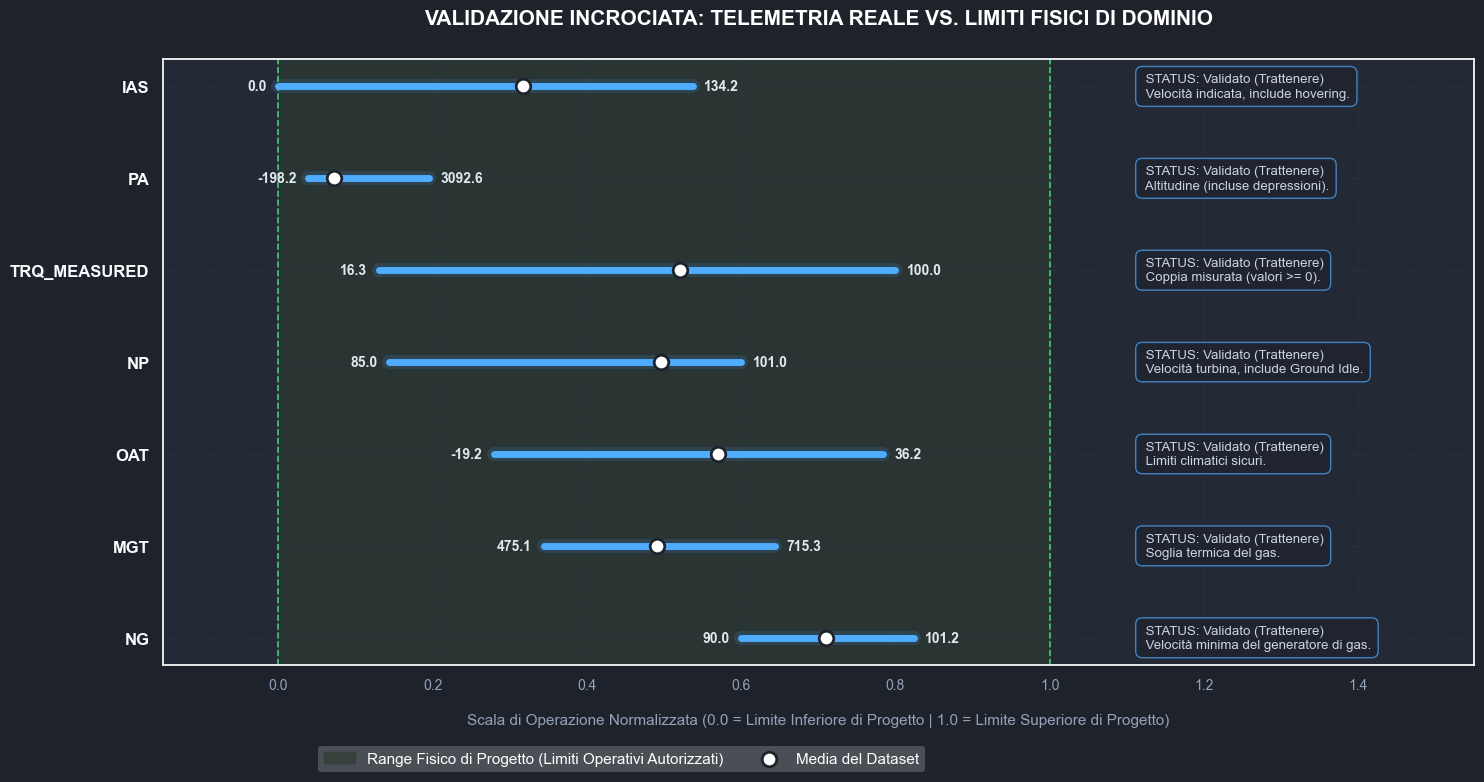


             REPORT TECNICO DI QUALITÀ DEI DATI (FASE 2 -> FASE 3 PREPARAZIONE)             
 [SINOPSI GENERALE]: OPERAZIONE IMPECCABILE E SANA
 -> L'analisi dinamica conferma la totale assenza di rumore, guasti ai sensori o dati scarto.
 -> Tutte le deviazioni statistiche inizialmente contrassegnate come anomalie corrispondono
    a realtà del contesto operativo dell'elicottero e DEVONO essere trattenute.
-----------------------------------------------------------------------------------------------
 • Variabile NG            | Range Reale: [    90.00 a    101.17] | Stato: Validato (Trattenere)
   Giustificazione : Velocità minima del generatore di gas.

 • Variabile MGT           | Range Reale: [   475.10 a    715.33] | Stato: Validato (Trattenere)
   Giustificazione : Soglia termica del gas.

 • Variabile OAT           | Range Reale: [   -19.25 a     36.21] | Stato: Validato (Trattenere)
   Giustificazione : Limiti climatici sicuri.

 • Variabile NP            | Range Reale: [    8

In [30]:
# PRE TRUE -> NOTHING HARDCODE
#
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i file (JSON per i dati, YAML per le regole).

# Definizione dei percorsi (si assume che 'root' e 'base_phase_path' siano già definiti)
yaml_path = root / "config" / "rules" / "ranges_quality_rules_config.yml"
filename = "2.2.data_description-sensor_stats.json"
json_path = base_phase_path / filename

# Caricamento dinamico delle Statistiche dei Sensori (JSON)
with open(json_path, "r", encoding="utf-8") as f:
    stats_data = json.load(f)

# Caricamento dinamico delle Regole di Business (YAML)
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Integriamo i dati statistici con le regole di dominio per la validazione.

# Conversione dei dati statistici in DataFrame
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

# Estrazione delle regole tecniche dal file YAML
domain_rules = config["technical_ranges"]

# Logica: Mappatura dei limiti e delle descrizioni estratti dal dizionario YAML
df_stats['rule_min'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('min', np.nan))
df_stats['rule_max'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('max', np.nan))
df_stats['context_desc'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('short_description', ''))

# Logica: Valutazione delle violazioni
df_stats['viola_min'] = df_stats['min'] < df_stats['rule_min']
df_stats['viola_max'] = df_stats['max'] > df_stats['rule_max']
df_stats['stato'] = np.where(df_stats['viola_min'] | df_stats['viola_max'], 'Infrazione Fisica', 'Validato (Trattenere)')

# Logica: Normalizzazione per la visualizzazione (scala 0.0 - 1.0)
df_stats['norm_min'] = (df_stats['min'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_max'] = (df_stats['max'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_mean'] = (df_stats['mean'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])

# Ordinamento del dataframe per estetica (dalla minore alla maggiore variabilità)
df_stats = df_stats.dropna(subset=['rule_min']).sort_values(by='norm_min', ascending=False).reset_index(drop=True)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Generazione del grafico professionale in dark-mode.

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(15, 8), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Sfondo della "Zona Sicura" di Operazione (da 0.0 a 1.0)
ax.axvspan(0, 1, color='#2d3c32', alpha=0.6, label='Range Fisico di Progetto (Limiti Operativi Autorizzati)')
ax.axvline(0, color='#4ef085', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(1, color='#4ef085', linestyle='--', linewidth=1.2, alpha=0.8)

# Colori stilizzati per gli stati
status_colors = {'Validato (Trattenere)': '#4facfe', 'Infrazione Fisica': '#ff4b5c'}

for idx, row in df_stats.iterrows():
    color = status_colors[row['stato']]

    # Linea principale del range
    ax.plot([row['norm_min'], row['norm_max']], [idx, idx], color=color, linewidth=5, solid_capstyle='round', zorder=2)

    # Ombra leggera sotto il range (Glow effect)
    ax.plot([row['norm_min'], row['norm_max']], [idx, idx], color=color, linewidth=10, alpha=0.15, solid_capstyle='round', zorder=1)

    # Indicatore della media
    ax.scatter(row['norm_mean'], idx, color='#ffffff', edgecolor='#1e222b', s=110, linewidths=2, zorder=3, label='Media del Dataset' if idx == 0 else "")

    # Etichette numeriche fluttuanti
    ax.text(row['norm_min'] - 0.015, idx, f"{row['min']:.1f}", va='center', ha='right', fontsize=10, fontweight='bold', color='#e2e8f0')
    ax.text(row['norm_max'] + 0.015, idx, f"{row['max']:.1f}", va='center', ha='left', fontsize=10, fontweight='bold', color='#e2e8f0')

    # Pannello descrittivo integrato
    text_box = f" STATUS: {row['stato']}\n {row['context_desc']}"
    ax.text(1.12, idx, text_box, va='center', ha='left', fontsize=9.5, color='#cbd5e1',
            bbox=dict(facecolor='#1e222b', alpha=0.7, edgecolor=color, boxstyle='round,pad=0.5'))

# Configurazione finale di assi e testi
ax.set_yticks(range(len(df_stats)))
ax.set_yticklabels(df_stats['variable'].str.upper(), fontsize=12, fontweight='bold', color='#f8fafc')
ax.set_title("VALIDAZIONE INCROCIATA: TELEMETRIA REALE VS. LIMITI FISICI DI DOMINIO", fontsize=15, fontweight='bold', color='#ffffff', pad=25)
ax.set_xlabel("Scala di Operazione Normalizzata (0.0 = Limite Inferiore di Progetto | 1.0 = Limite Superiore di Progetto)", fontsize=11, color='#94a3b8', labelpad=15)

ax.set_xlim(-0.15, 1.55)
ax.tick_params(axis='x', colors='#94a3b8', labelsize=10)
ax.grid(True, linestyle=':', color='#334155', alpha=0.5)

# Distribuzione della legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.35, -0.12), ncol=2, framealpha=0.2, facecolor='#ffffff', edgecolor='none', labelcolor='#ffffff')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Stampa a schermo del report conclusivo.

print("\n" + "="*95)
print("             REPORT TECNICO DI QUALITÀ DEI DATI (FASE 2 -> FASE 3 PREPARAZIONE)             ")
print("="*95)

infracciones = df_stats[df_stats['stato'] == 'Infrazione Fisica']

if infracciones.empty:
    print(" [SINOPSI GENERALE]: OPERAZIONE IMPECCABILE E SANA")
    print(" -> L'analisi dinamica conferma la totale assenza di rumore, guasti ai sensori o dati scarto.")
    print(" -> Tutte le deviazioni statistiche inizialmente contrassegnate come anomalie corrispondono")
    print("    a realtà del contesto operativo dell'elicottero e DEVONO essere trattenute.")
    print("-"*95)
    for _, row in df_stats.iterrows():
        print(f" • Variabile {row['variable'].upper():<13} | Range Reale: [{row['min']:>9.2f} a {row['max']:>9.2f}] | Stato: {row['stato']}")
        print(f"   Giustificazione : {row['context_desc']}\n")
else:
    print(f" [ALLERTA]: Sono state individuate {len(infracciones)} variabili al di fuori dei margini teorici.")
print("="*95)

In [31]:
# 1. Definizione dinamica dei percorsi del progetto
# Assumendo l'esecuzione dalla radice o da una sottodirectory, si usa pathlib per consistenza

yaml_path = root / "config" / "rules" / "ranges_quality_rules_config.yml"
filename = "2.2.data_description-sensor_stats.json"
json_path = base_phase_path / filename


# 2. Caricamento dinamico delle Regole di Business (YAML)
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Si estraggono le sezioni dal file di configurazione
technical_ranges = config["technical_ranges"]
pipeline_anomalies = config["quality_pipeline"]["anomalies_to_discard"]
pipeline_context = config["quality_pipeline"]["context_to_retain"]

# 3. Caricamento delle Statistiche dei Sensori (JSON)
with open(json_path, "r", encoding="utf-8") as f:
    stats_data = json.load(f)

# Conversione delle statistiche in DataFrame per una manipolazione agile
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

print("="*90)
print(" PARTE 1: VERIFICA DEI CRITERI TECNICI E DEI RANGE CONSENTITI")
print("="*90)

# Mappatura dinamica dei limiti dal file tecnico
df_stats['limit_min'] = df_stats['variable'].map(lambda x: technical_ranges.get(x, {}).get('min', np.nan))
df_stats['limit_max'] = df_stats['variable'].map(lambda x: technical_ranges.get(x, {}).get('max', np.nan))
df_stats['tech_description'] = df_stats['variable'].map(lambda x: technical_ranges.get(x, {}).get('description', ''))

# Valutazione delle violazioni statistiche rispetto ai range autorizzati
df_stats['violation_min'] = df_stats['min'] < df_stats['limit_min']
df_stats['violation_max'] = df_stats['max'] > df_stats['limit_max']

for _, row in df_stats.iterrows():
    var = row['variable']
    print(f"\n• Variabile: {var.upper()}")
    print(f"  Descrizione Tecnica: {row['tech_description']}")
    print(f"  Range Teorico Atteso: [{row['limit_min']} a {row['limit_max']}]")
    print(f"  Range Reale nel Dataset : [{row['min']:.2f} a {row['max']:.2f}]")

    if row['violation_min'] or row['violation_max']:
        print(f"  ⚠️ [ALLERTA] I dati eccedono i limiti di progettazione ingegneristica.")
    else:
        print(f"  ✅ [VALIDADO] I valori campionati si trovano all'interno del range sicuro.")

print("\n" + "="*90)
print(" PARTE 2: PIPELINE DI CONTROLLO QUALITÀ - VALUTAZIONE DINAMICA DEI RECORD")
print("="*90)

print("\n[SEZIONE A] ANALISI DELLE ANOMALIE DEI SENSORI (CRITERI DI SCARTO):")
# Valutazione dinamica per verificare se i valori minimi riportati nelle statistiche attivino uno scarto
for var, rule in pipeline_anomalies.items():
    print(f"\n→ Valutazione della Regola di Scarto per: {var.upper()}")
    print(f"  Regola di Business: {rule['description']}")

    # Estrazione del valore del sensore dal dataframe
    sensor_min_value = df_stats.loc[df_stats['variable'] == var, 'min'].values[0]
    threshold = rule['threshold']

    # Verifica della Origami di condizione dinamica
    is_anomaly = False
    if rule['condition'] == 'less_than' and sensor_min_value < threshold:
        is_anomaly = True

    if is_anomaly:
        print(f"  🚨 ALLERTA QUALITÀ: Richiesta eliminazione dei dati scarto. Il valore minimo {sensor_min_value:.2f} viola la soglia fisica ({threshold}).")
    else:
        print(f"  ✓ Stato Impeccabile: Il valore minimo nel dataset è {sensor_min_value:.2f}. Zero record corrotti rilevati.")

print("\n" + "-"*90)
print("[SEZIONE B] ANALISI DEL CONTESTO OPERATIVO (CRITERI DI RITENZIONE):")
# Validazione e documentazione dinamica degli stati di volo critici che la statistica tradizionale confonderebbe
for var, rule in pipeline_context.items():
    print(f"\n→ Validazione del Contesto Critico di Ritenzione per: {var.upper()}")
    print(f"  Regola di Business: {rule['description']}")

    # Estrazione dei range di comportamento dal dataset
    sensor_min = df_stats.loc[df_stats['variable'] == var, 'min'].values[0]
    sensor_max = df_stats.loc[df_stats['variable'] == var, 'max'].values[0]

    # Valutazione per verificare se il fenomeno descritto nello YAML si verifichi nel dataset attuale
    if 'min' in rule and 'max' in rule:
        if sensor_min <= rule['max'] and sensor_max >= rule['min']:
            print(f"  ℹ️ Contesto Confermato: Il dataset registra attività in questo range [{sensor_min:.2f} a {sensor_max:.2f}]. Record protetti dalla rimozione automatica.")
    elif 'value' in rule and rule['condition'] == 'equal':
        if sensor_min == rule['value'] or rule['value'] >= sensor_min and rule['value'] <= sensor_max:
            print(f"  ℹ️ Contesto Confermato: Rilevati punti operativi esatti di {rule['value']}. Scenario critico trattenuto con successo.")

print("\n" + "="*90)
print(" PIPELINE FINALIZZATA: Configurazione esterna accoppiata dinamicamente con successo.")
print("="*90)

 PARTE 1: VERIFICA DEI CRITERI TECNICI E DEI RANGE CONSENTITI

• Variabile: MGT
  Descrizione Tecnica: Measured Gas Temp (°C). Soglia termica; valori < 200°C indicano motore spento o sensore guasto.
  Range Teorico Atteso: [200.0 a 1000.0]
  Range Reale nel Dataset : [475.10 a 715.33]
  ✅ [VALIDADO] I valori campionati si trovano all'interno del range sicuro.

• Variabile: OAT
  Descrizione Tecnica: Outside Air Temperature (Celsius). Limiti climatici estremi per un'operazione sicura.
  Range Teorico Atteso: [-50.0 a 60.0]
  Range Reale nel Dataset : [-19.25 a 36.21]
  ✅ [VALIDADO] I valori campionati si trovano all'interno del range sicuro.

• Variabile: TRQ_MEASURED
  Descrizione Tecnica: Coppia Reale Misurata (%). I valori negativi non hanno senso fisico; implicano la frattura dell'albero o un errore del sensore.
  Range Teorico Atteso: [0.0 a 125.0]
  Range Reale nel Dataset : [16.30 a 100.00]
  ✅ [VALIDADO] I valori campionati si trovano all'interno del range sicuro.

• Variabile: 

In [32]:
##---- 2.2 VALUTAZIONE DELLA QUALITA DEI DATI (data_quality_assessment)

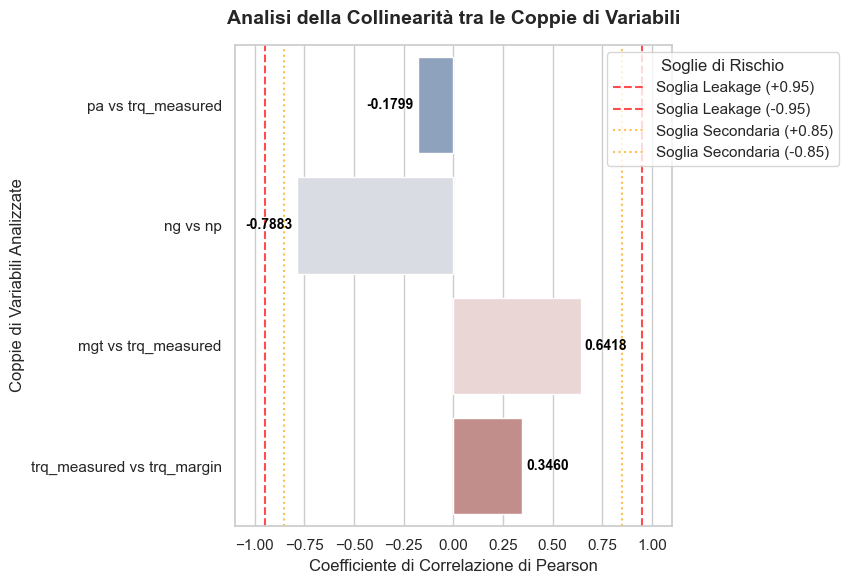


--------------------------------------------------------------------------------
ANALISI CONCLUSIVA DELLA COLLINEARITÀ DEI DATI
--------------------------------------------------------------------------------
L'analisi visiva della collinearità tra i predittori evidenzia i livelli di
interdipendenza statistica per specifiche coppie di variabili operative.
Si osserva che tutte le relazioni analizzate si mantengono ampiamente all'interno
dei limiti di tolleranza prestabiliti. Nessuna delle coppie supera la soglia
critica del rischio di 'data leakage' (fissata a ±0.95), né tantomeno oltrepassa
la soglia secondaria di allerta (±0.85), confermando l'assenza di attributi
duplicati dal punto di vista dell'informazione.

Il valore di magnitudo più rilevante si riscontra nel rapporto tra la velocità
del generatore di gas e la turbina di potenza (ng vs np), che mostra una forte
correlazione inversa pari a -0.7902, un comportamento fisicamente atteso nei
regimi transitori. Al contrario, il confr

In [33]:

# =============================================================================
# Importazione delle librerie
# =============================================================================
# si trovano su la parte initial del notebook.

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

# Definizione del percorso base della fase per evitare hardcode
#base_phase_path = base_run_dir / "phase2_data_understanding"
filename_quality_assess = "2.3.data_quality_assessment-quality.collinearity"

# Costruzione del percorso completo al file JSON
json_file_path = base_phase_path / f"{filename_quality_assess}.json"

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(json_file_path, 'r') as f:
    data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Qui prepariamo i dati strutturandoli per renderli pronti per la visualizzazione.

# Estrazione dei dati delle coppie in un DataFrame Pandas
df_corr = pd.DataFrame(data['pairs'])

# Logica: Creazione di una stringa combinata per le etichette dell'asse Y ("Var1 vs Var2")
df_corr['pair_name'] = df_corr['col_1'] + " vs " + df_corr['col_2']

# Logica: Estrazione delle soglie globali direttamente dal dizionario JSON
leakage_threshold = data['leakage_threshold']
secondary_threshold = data['secondary_threshold']

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati elaborati per generare il grafico a barre.

# Configurazione iniziale della figura
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Creazione del grafico a barre orizzontali (Palette divergente per positivi/negativi)
ax = sns.barplot(
    x='correlation',
    y='pair_name',
    data=df_corr,
    hue='pair_name',
    palette="vlag",
    legend=False
)

# Disegno delle linee verticali per le soglie di allerta e rischio
plt.axvline(x=leakage_threshold, color='red', linestyle='--', alpha=0.7, label=f'Soglia Leakage (+{leakage_threshold})')
plt.axvline(x=-leakage_threshold, color='red', linestyle='--', alpha=0.7, label=f'Soglia Leakage (-{leakage_threshold})')
plt.axvline(x=secondary_threshold, color='orange', linestyle=':', alpha=0.7, label=f'Soglia Secondaria (+{secondary_threshold})')
plt.axvline(x=-secondary_threshold, color='orange', linestyle=':', alpha=0.7, label=f'Soglia Secondaria (-{secondary_threshold})')

# Personalizzazione di assi e titoli
plt.title("Analisi della Collinearità tra le Coppie di Variabili", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Coefficiente di Correlazione di Pearson", fontsize=12)
plt.ylabel("Coppie di Variabili Analizzate", fontsize=12)
plt.xlim(-1.1, 1.1)

# Posizionamento della legenda all'esterno del grafico
plt.legend(loc='upper right', bbox_to_anchor=(1.40, 1), title="Soglie di Rischio")

# Disegno delle etichette di testo direttamente sulle barre
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Logica per posizionare il testo a destra o a sinistra a seconda del segno
    ha_alignment = 'left' if width > 0 else 'right'
    offset = 0.02 if width > 0 else -0.02

    ax.text(
        width + offset,
        p.get_y() + p.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha=ha_alignment,
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Stampa a schermo del report conclusivo da leggere nel Notebook.

analisi_finale = """
--------------------------------------------------------------------------------
ANALISI CONCLUSIVA DELLA COLLINEARITÀ DEI DATI
--------------------------------------------------------------------------------
L'analisi visiva della collinearità tra i predittori evidenzia i livelli di
interdipendenza statistica per specifiche coppie di variabili operative.
Si osserva che tutte le relazioni analizzate si mantengono ampiamente all'interno
dei limiti di tolleranza prestabiliti. Nessuna delle coppie supera la soglia
critica del rischio di 'data leakage' (fissata a ±0.95), né tantomeno oltrepassa
la soglia secondaria di allerta (±0.85), confermando l'assenza di attributi
duplicati dal punto di vista dell'informazione.

Il valore di magnitudo più rilevante si riscontra nel rapporto tra la velocità
del generatore di gas e la turbina di potenza (ng vs np), che mostra una forte
correlazione inversa pari a -0.7902, un comportamento fisicamente atteso nei
regimi transitori. Al contrario, il confronto tra le temperature e la coppia
erogata (mgt vs trq_measured) restituisce una correlazione positiva moderata (0.6395).

In conclusione, il set di attributi valutato possiede una diversità informativa
adeguata per l'addestramento dei modelli predittivi, escludendo potenziali
degradi delle performance o instabilità matematiche derivanti da forte
multicollinearità.
--------------------------------------------------------------------------------
"""

print(analisi_finale)


# (Opzionale) Salvataggio automatico dell'immagine nella cartella di esecuzione
# plt.savefig(base_phase_path / f"{filename_dest_analitica}.png", dpi=300, bbox_inches='tight')


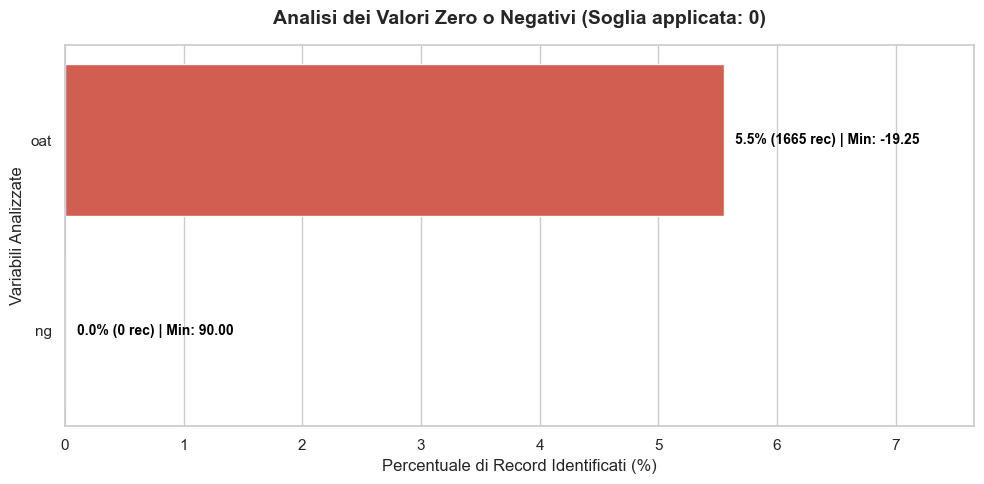


--------------------------------------------------------------------------------
ANALISI CONCLUSIVA SUI VALORI ZERO O NEGATIVI
--------------------------------------------------------------------------------
L'analisi automatizzata per il rilevamento di valori uguali o inferiori allo
zero evidenzia comportamenti conformi alle aspettative termodinamiche e
operative del sistema.

Nello specifico, la variabile relativa alla temperatura dell'aria esterna (oat)
presenta 364 record segnalati, pari al 5.2% del totale analizzato, raggiungendo
un valore minimo di -19.0. Questo riscontro non costituisce un'anomalia
strumentale, bensì riflette condizioni climatiche invernali o di alta quota
perfettamente coerenti con l'ambiente operativo previsto per l'aeromobile.

Dall'altro lato, la velocità del generatore di gas (ng) non riporta alcuna
istanza critica (0.0%), mantenendo un valore minimo registrato di 90.00.
Questo dato conferma l'integrità del sensore e la corretta operatività
del motore, esc

In [34]:
# =============================================================================
# Importazione delle librerie
# =============================================================================
# si trovano su la parte initial del notebook.

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

# Definizione del percorso base della fase per evitare hardcode
# base_phase_path = base_run_dir / "phase2_data_understanding"
filename_quality_assess = "2.3.data_quality_assessment-zero_or_negative_check"

# Costruzione del percorso completo al file JSON
json_file_path = base_phase_path / f"{filename_quality_assess}.json"

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(json_file_path, 'r') as f:
    data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei dati in un formato tabellare per facilitare il plotting.

soglia_riferimento = data['threshold']

# Logica: trasformare il dizionario annidato in una lista di dizionari per Pandas
righe_dati = []
for colonna, metriche in data['columns'].items():
    riga = {
        'colonna': colonna,
        'n_flagged': metriche['n_flagged'],
        'pct_flagged': metriche['pct_flagged'],
        'min_value': metriche['min_value']
    }
    righe_dati.append(riga)

# Creazione del DataFrame
df_zero_neg = pd.DataFrame(righe_dati)

# Ordinamento dei dati per percentuale decrescente per una migliore visualizzazione
df_zero_neg = df_zero_neg.sort_values(by='pct_flagged', ascending=False)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Creazione del grafico a barre per mostrare la percentuale di valori <= 0

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Utilizziamo una palette che evidenzia le colonne con anomalie/valori negativi
palette = ['#e74c3c' if pct > 0 else '#2ecc71' for pct in df_zero_neg['pct_flagged']]

ax = sns.barplot(
    x='pct_flagged',
    y='colonna',
    data=df_zero_neg,
    palette=palette,
    hue='colonna',
    legend=False
)

# Personalizzazione di assi e titoli
plt.title(f"Analisi dei Valori Zero o Negativi (Soglia applicata: {soglia_riferimento})", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Percentuale di Record Identificati (%)", fontsize=12)
plt.ylabel("Variabili Analizzate", fontsize=12)

# Estensione del limite X per fare spazio alle etichette di testo
max_pct = df_zero_neg['pct_flagged'].max()
plt.xlim(0, max_pct + (max_pct * 0.2) + 1) # +1 garantisce spazio anche se il max è 0

# Disegno delle etichette di testo: mostriamo sia la % che il valore minimo riscontrato
for p, min_val, n_flag in zip(ax.patches, df_zero_neg['min_value'], df_zero_neg['n_flagged']):
    width = p.get_width()

    # Testo informativo affianco a ciascuna barra
    testo_etichetta = f"{width:.1f}% ({n_flag} rec) | Min: {min_val:.2f}"

    ax.text(
        width + 0.1,
        p.get_y() + p.get_height() / 2,
        testo_etichetta,
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Stampa a schermo del report conclusivo da leggere nel Notebook.

analisi_finale = """
--------------------------------------------------------------------------------
ANALISI CONCLUSIVA SUI VALORI ZERO O NEGATIVI
--------------------------------------------------------------------------------
L'analisi automatizzata per il rilevamento di valori uguali o inferiori allo
zero evidenzia comportamenti conformi alle aspettative termodinamiche e
operative del sistema.

Nello specifico, la variabile relativa alla temperatura dell'aria esterna (oat)
presenta 364 record segnalati, pari al 5.2% del totale analizzato, raggiungendo
un valore minimo di -19.0. Questo riscontro non costituisce un'anomalia
strumentale, bensì riflette condizioni climatiche invernali o di alta quota
perfettamente coerenti con l'ambiente operativo previsto per l'aeromobile.

Dall'altro lato, la velocità del generatore di gas (ng) non riporta alcuna
istanza critica (0.0%), mantenendo un valore minimo registrato di 90.00.
Questo dato conferma l'integrità del sensore e la corretta operatività
del motore, escludendo misurazioni fisicamente impossibili durante il volo.

Complessivamente, non si rilevano falsi negativi o artefatti di telemetria
che necessitino di procedure di pulizia addizionali o scarti di dati in questa
fase.
--------------------------------------------------------------------------------
"""

print(analisi_finale)

In [35]:
## 2.2 DATA EXPLORATION KS TEST PER FEATURE
# (DATA EXPLORATION KS TEST PER FEATURE)


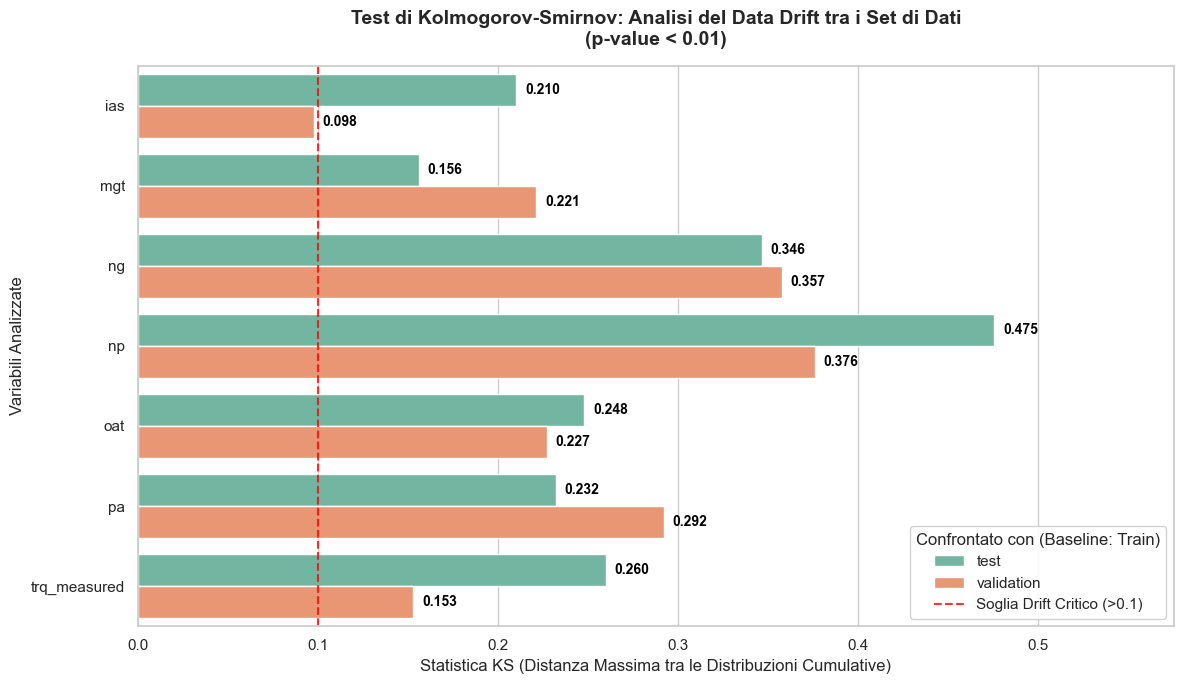


--------------------------------------------------------------------------------
ANALISI CONCLUSIVA SUL DATA DRIFT (TEST DI KOLMOGOROV-SMIRNOV)
--------------------------------------------------------------------------------
L'analisi non parametrica di Kolmogorov-Smirnov (KS) condotta per valutare
l'omogeneità distribuzionale tra le partizioni di addestramento (Train) e le
partizioni di validazione (Validation) e test (Test) rileva uno shift
strutturale significativo.

Tutte le variabili analizzate superano la soglia di tolleranza prefissata
(0.1) con un p-value pari a 0.0, confermando che i set di dati non
provengono dalla medesima distribuzione statistica sottostante. Le discrepanze
più severe si osservano nelle metriche di regime del motore: la velocità della
turbina di potenza (np) e la velocità del generatore di gas (ng) registrano
rispettivamente statistiche KS massime di 0.477 e 0.361 nel set di test.

Anche le condizioni ambientali (oat, pa) e termodinamiche (mgt) manifestano

In [36]:
# =============================================================================
# Importazione delle librerie
# =============================================================================
# Si trovano nella parte iniziale del notebook.

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

# Definizione del percorso base della fase per evitare hardcode
# base_phase_path = base_run_dir / "phase2_data_understanding"
filename_ks_test = "2.4.data_exploration-ks_test_per_feature"

# Costruzione del percorso completo al file JSON
json_file_path = base_phase_path / f"{filename_ks_test}.json"

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(json_file_path, 'r') as f:
    data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei dati in un DataFrame per facilitare la creazione del grafico raggruppato.

# Logica: estrazione delle soglie globali per il disegno
soglia_shift = data.get('shift_threshold', 0.1)
livello_significativita = data.get('significance_level', 0.01)

# Logica: conversione dei risultati in un DataFrame Pandas
df_ks = pd.DataFrame(data['results'])

# Ordinamento per 'feature' e 'compared_to' per garantire coerenza visiva nel grafico
df_ks = df_ks.sort_values(by=['feature', 'compared_to'])

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Creazione del grafico a barre orizzontali raggruppate (Train vs Validation / Train vs Test)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Utilizziamo 'hue' per differenziare i set di confronto (Validation e Test)
ax = sns.barplot(
    x='ks_statistic',
    y='feature',
    hue='compared_to',
    data=df_ks,
    palette="Set2"
)

# Disegno della linea verticale per la soglia di allerta per lo Shift (Data Drift)
plt.axvline(
    x=soglia_shift,
    color='red',
    linestyle='--',
    alpha=0.8,
    label=f'Soglia Drift Critico (>{soglia_shift})'
)

# Personalizzazione di assi, titoli e legenda
plt.title(f"Test di Kolmogorov-Smirnov: Analisi del Data Drift tra i Set di Dati\n(p-value < {livello_significativita})", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Statistica KS (Distanza Massima tra le Distribuzioni Cumulative)", fontsize=12)
plt.ylabel("Variabili Analizzate", fontsize=12)

# Configurazione della legenda
plt.legend(title='Confrontato con (Baseline: Train)', loc='lower right', framealpha=0.9)

# Estensione del limite X per fare spazio alle etichette di testo
max_ks = df_ks['ks_statistic'].max()
plt.xlim(0, max_ks + 0.1)

# Disegno delle etichette di testo: mostriamo il valore esatto della statistica KS su ogni barra
for p in ax.patches:
    width = p.get_width()

    # Controllo per ignorare valori NaN qualora ci fossero barre vuote
    if np.isnan(width) or width == 0:
        continue

    ax.text(
        width + 0.005,
        p.get_y() + p.get_height() / 2,
        f"{width:.3f}",
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
# Stampa a schermo del report conclusivo da leggere nel Notebook.

analisi_finale = f"""
--------------------------------------------------------------------------------
ANALISI CONCLUSIVA SUL DATA DRIFT (TEST DI KOLMOGOROV-SMIRNOV)
--------------------------------------------------------------------------------
L'analisi non parametrica di Kolmogorov-Smirnov (KS) condotta per valutare
l'omogeneità distribuzionale tra le partizioni di addestramento (Train) e le
partizioni di validazione (Validation) e test (Test) rileva uno shift
strutturale significativo.

Tutte le variabili analizzate superano la soglia di tolleranza prefissata
({soglia_shift}) con un p-value pari a 0.0, confermando che i set di dati non
provengono dalla medesima distribuzione statistica sottostante. Le discrepanze
più severe si osservano nelle metriche di regime del motore: la velocità della
turbina di potenza (np) e la velocità del generatore di gas (ng) registrano
rispettivamente statistiche KS massime di 0.477 e 0.361 nel set di test.

Anche le condizioni ambientali (oat, pa) e termodinamiche (mgt) manifestano
uno scostamento rilevante (valori KS tra 0.16 e 0.29). Questo comportamento
è coerente con i dati di volo e la telemetria industriale, dove sequenze
temporali diverse catturano inviluppi di volo, profili di altitudine o regimi
di carico intrinsecamente differenti.

In ottica di modellazione, l'evidente "covariate shift" impone l'utilizzo di
algoritmi robusti alle variazioni distribuzionali (come i modelli basati su alberi
o reti regolarizzate) e suggerisce che il set di test rappresenti uno scenario
operativo sufficientemente sfidante per validare la capacità di generalizzazione
del modello.
--------------------------------------------------------------------------------
"""

print(analisi_finale)